In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from obspy import UTCDateTime
import itertools

import proba_modules as pm

In [ ]:
reload(pm)

def find_file(file_traj, pattern, freq, Terup, ivolc, date_loc=UTCDateTime('2026-03-24'), cpt_max=1):

    file = 'dummy'
    cpt = 0
    while not os.path.exists(file) and cpt < cpt_max:
        file = f'{file_traj}{pattern.format(date=date_loc.strftime("%Y-%m-%d"), freq=freq, Terup=Terup, ivolc=ivolc)}'
        date_loc += 3600*24
        cpt += 1

    return file

file_traj = '/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/'
pattern = 'trajectories_{date}_new_{freq}Hz_{Terup}s_v{ivolc}.csv'

freqs = [0.05, 0.1, 0.5]
ivolcs = [0, 1]
istart = 3
T_eruption = np.logspace(0,2,6)[4] # Float numbers need to be exact
time = 12
file_date = '2026-05-01'

trajectory_allparam = pd.DataFrame()
probas = dict()
for freq in freqs:
    probas[freq] = []
    for cpt_volc, ivolc in enumerate(ivolcs):
        file = find_file(file_traj, pattern, freq, T_eruption, ivolc, date_loc=UTCDateTime(file_date))
        trajectory = pd.read_csv(file, header=[0])
        print(T_eruption, trajectory.T_eruption.unique())
        trajectory = trajectory.loc[(trajectory.istart==istart)&(trajectory.T_eruption==T_eruption)&(trajectory.ivolcano==ivolc)]
        trajectory.loc[:,'ivolcano'] = cpt_volc
        trajectory_allparam = pd.concat([trajectory_allparam, trajectory])

        model_name = f'probas_{freq}Hz_{T_eruption}s_v{ivolc}_{time}h.h5'
        folder_save_proba_map = '/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/'
        probas[freq].append( pm.proba_model_stf.load_h5(f"{folder_save_proba_map}{model_name}") )

trajectory_allparam.reset_index(drop=True, inplace=True)

                time  proba_loc        lat        lon  snr  time_ust  \
0       0.000000e+00   0.001125 -85.000000   0.000000  1.0         0   
1       3.600000e+03   0.001293 -84.985384 -10.516420  1.0         0   
2       7.200000e+03   0.001681 -84.931533 -21.507493  1.0         0   
3       1.080000e+04   0.001769 -84.850540 -31.511423  1.0         0   
4       1.440000e+04   0.001769 -84.740100 -41.493605  1.0         0   
...              ...        ...        ...        ...  ...       ...   
131011  1.553930e+07   0.027593  85.009407  96.493183  5.0        13   
131012  1.554290e+07   0.028818  85.107389  87.487277  5.0        13   
131013  1.554650e+07   0.029643  85.230421  76.779530  5.0        13   
131014  1.555010e+07   0.030047  85.346041  66.469843  5.0        13   
131015  1.555370e+07   0.033060  85.411926  60.480518  5.0        13   

        isection_time     proba  freq  ivolcano  T_eruption  istart  \
0                   0  0.001125  0.05         1   15.848932     

Subsolar longitude: 0.0


/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:2396: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  #sc = m.pcolormesh(x, y, proba_test, cmap=cmap, vmax=vmax, vmin=vmin)
/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:2396: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  #sc = m.pcolormesh(x, y, proba_test, cmap=cmap, vmax=vmax, vmin=vmin)
/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:2396: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. Thi

./figures/Figure6_probas_traj_TLseasonal_lst12_39.810717055349734s_istart3_rhoscaled.pdf


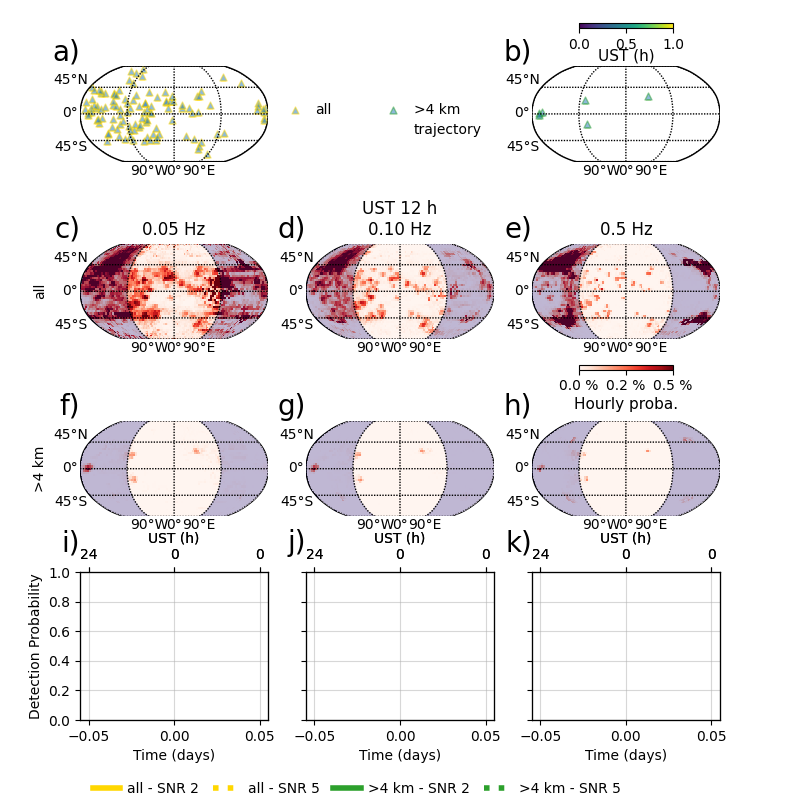

In [19]:
reload(pm)

folder_volcano = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_volcanoes/'
#files_volcanoes = [f'{folder_volcano}05_large_greaterthan100.csv', f'{folder_volcano}05_large_greaterthan100_sophus_Heightabove4km.csv',]
files_volcanoes = [f'{folder_volcano}05_large_greaterthan100_sophus.csv', f'{folder_volcano}05_large_greaterthan100_sophus_Heightabove4km.csv',]
opt_figure = dict(
    files_volcanoes=files_volcanoes, 
    lst=time,
    snr_chosen=2., 
    other_snr_chosen=[5.],
    cmap='Reds', 
    n_hours=1, 
    #vmax=3e-3, # old
    vmax=5e-3,
    vmin=0,
    labels_volcanoes = ['all', '>4 km',],
    mapping_ax = {0.05: 0, 0.1: 1, 0.5: 2},
    file=f'./figures/Figure6_probas_traj_TLseasonal_lst{time}_{T_eruption}s_istart{istart}_rhoscaled.pdf'
)
pm.plot_Figure_probas(probas, trajectory_allparam, **opt_figure)

In [6]:
probas_allUST = []
freq = 0.5
ivolc = 0
T_eruption = 50.
istart = 2
dropoff_hour_UST = 1
times_TL = np.arange(0,24)

trajectory_df=pd.read_csv('./trajectories/trajectory_paths.csv', header=[0])
trajectory = []
for itraj, traj in trajectory_df.groupby('drop_off_idx'):
    lat, lon = traj.iloc[0].drop_off_lat, traj.iloc[0].drop_off_lon
    trajectory.append(traj)

for time in times_TL:
    model_name = f'probas_{freq}Hz_{T_eruption}s_v{ivolc}_{time}h.h5'
    folder_save_proba_map = '/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/'
    probas_allUST.append( pm.proba_model_stf.load_h5(f"{folder_save_proba_map}{model_name}") )
    #plt.figure()
    #plt.pcolormesh(probas_allUST[-1].proba_all[0,:,:])

In [7]:
reload(pm)

new_trajectories = pm.compute_proba_trajectory(probas_allUST, times_TL, trajectory[istart], dropoff_hour_UST)

Running compute_proba_one_trajectory
- Building trajectory dt and bin_dt
- Building matrices
- Looping over snr and time


 33%|███▎      | 1/3 [00:00<00:00,  6.21it/s]

--- SNR: 1.0
itime 0
itime 1
itime 2
itime 3
itime 4
itime 5
itime 6
itime 7
itime 8
itime 9
itime 10
itime 11
itime 12
itime 13
itime 14
itime 15
itime 16
itime 17
itime 18
itime 19
itime 20
itime 21
itime 22
itime 23
--- SNR: 2.0
itime 0
itime 1
itime 2
itime 3
itime 4
itime 5


 67%|██████▋   | 2/3 [00:00<00:00,  6.17it/s]

itime 6
itime 7
itime 8
itime 9
itime 10
itime 11
itime 12
itime 13
itime 14
itime 15
itime 16
itime 17
itime 18
itime 19
itime 20
itime 21
itime 22
itime 23
--- SNR: 5.0
itime 0
itime 1
itime 2
itime 3
itime 4
itime 5
itime 6
itime 7
itime 8
itime 9
itime 10
itime 11
itime 12


100%|██████████| 3/3 [00:00<00:00,  6.23it/s]


itime 13
itime 14
itime 15
itime 16
itime 17
itime 18
itime 19
itime 20
itime 21
itime 22
itime 23


In [ ]:
new_trajectories['proba'] = -1.
for snr, new_trajectory_snr in new_trajectories.groupby('snr'):
    for isection_time in new_trajectory_snr.isection_time.unique():
        new_trajectory_isection_time = new_trajectory_snr.loc[new_trajectory_snr.isection_time==isection_time]
        ifirst_entry = new_trajectory_isection_time.iloc[0].name
        if new_trajectory_isection_time.iloc[0].time == 0:
            new_trajectories.loc[new_trajectories.index.isin(new_trajectory_isection_time.index), 'proba'] = new_trajectories.loc[new_trajectories.index.isin(new_trajectory_isection_time.index), 'proba_loc']
            continue
        prev_entry = new_trajectories.loc[new_trajectories.index==ifirst_entry-1].iloc[0]
        cumprod_last = 1.-prev_entry.proba
        prev_entry_orig = new_trajectory_snr.loc[new_trajectory_snr.index==ifirst_entry-1].iloc[0]
        cumprod_last_orig = 1.-prev_entry.proba_loc
        #print(new_trajectories.loc[new_trajectories.index.isin(new_trajectory_isection_time.index)].index, new_trajectory_isection_time.index)
        new_trajectories.loc[new_trajectories.index.isin(new_trajectory_isection_time.index), 'proba'] = 1.-(1.-new_trajectory_isection_time.proba_loc)*cumprod_last
        print(snr, isection_time, cumprod_last, cumprod_last_orig)

1.0 3 2.0 0.9747838258824932
1.0 5 1.4151788292537417 0.7075894146268709
1.0 7 0.7728046852661191 0.5460827065040521
1.0 9 0.5246886258744639 0.6789407930333454
1.0 11 0.49134114299949716 0.9364432899238311
1.0 13 0.360872198228374 0.7344636275019684
1.0 15 0.2746705911250762 0.7611298195691258
1.0 17 0.24387162747906654 0.8878694529332235
1.0 19 0.21591369481687628 0.8853579936657857
1.0 21 0.20638721297204643 0.9558782880682508
1.0 23 0.20361627808158256 0.9865740960858889
1.0 25 0.19999110554072397 0.9821960573338538
1.0 27 0.19431101942274265 0.9715983063215544
1.0 29 0.1885666573323428 0.9704372808733898
1.0 30 0.1743890269207795 0.9248136939364864
1.0 31 0.1630306127872161 0.9348673805105678
1.0 32 0.1476851212820932 0.905873558083527
1.0 33 0.143487913627514 0.9715800236466471
1.0 34 0.13758226203291435 0.9588421669442465
1.0 35 0.13361493677755187 0.9711639771236403
1.0 36 0.13042780339827043 0.9761468780650813
1.0 37 0.1266180614915604 0.9707904157898242
1.0 0 0.11851899813910

2.0 10 0.29291319734447974 0.9845340058984334
2.0 12 0.28011828821943163 0.956318427298444
2.0 14 0.20508467213286685 0.7321359609773606
2.0 16 0.14562363433900738 0.7100659099704104
2.0 18 0.0999328801928574 0.6862408059409968
2.0 20 0.0801492196069612 0.8020305174061195
2.0 22 0.07600059334603415 0.9482387192130967
2.0 24 0.07151327463757884 0.9409567937446974
2.0 26 0.06967088692966827 0.9742371228663834
2.0 28 0.0675609639815038 0.9697158592182928
5.0 3 2.0 0.988790565773007
5.0 5 1.7244656532147629 0.8622328266073814
5.0 7 1.358152895873627 0.7875789774889094
5.0 9 1.1843373671042488 0.8720206470880644
5.0 11 1.151380116974856 0.9721724138367985
5.0 13 1.0441781716070329 0.9068926553556558
5.0 15 0.9471149803002981 0.9070434587256784
5.0 17 0.9177098665623437 0.9689529631041935
5.0 19 0.8815670030392303 0.9606162417556856
5.0 21 0.8661241249138224 0.9824824680686005
5.0 23 0.8631213661644557 0.9965331080580794
5.0 25 0.8581847578824602 0.9942805166509401
5.0 27 0.8476384911176832 

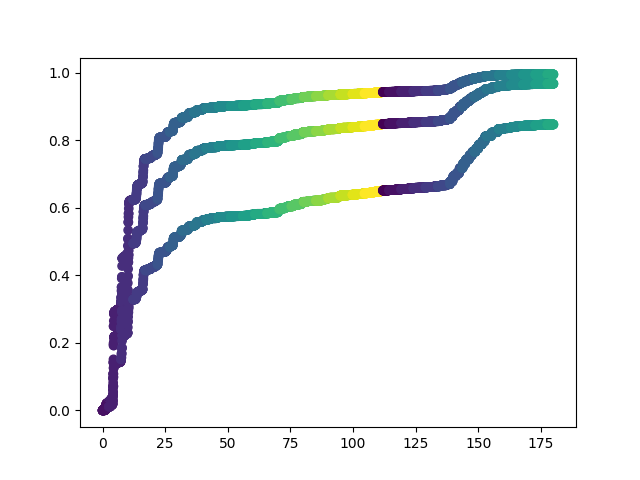

In [10]:
new_trajectories.sort_values(by=['snr','time'], inplace=True)
plt.figure()
for snr, new_trajectories_snr in new_trajectories.groupby('snr'):
    plt.scatter(new_trajectories_snr.time/3600./24, new_trajectories_snr.proba, c=new_trajectories_snr.time_ust)

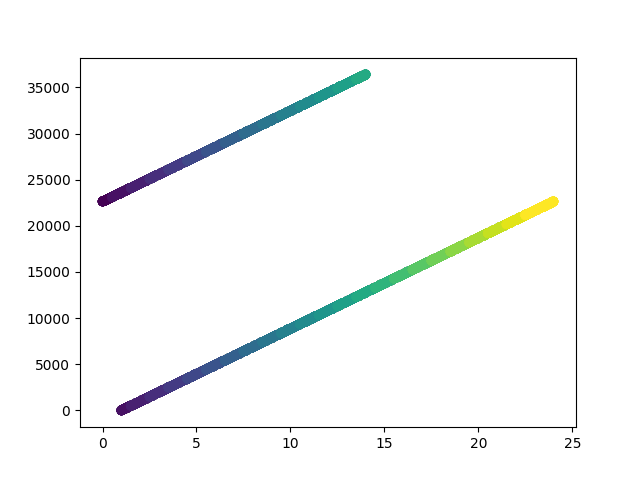

In [81]:
earth_days_UST=116.75
current_time = dropoff_hour_UST + trajectory[0].time.values/3600./earth_days_UST
current_time_hours = (current_time)%24
icurrent_time = np.abs(current_time_hours[:, None] - times_TL).argmin(axis=1)

plt.figure()
plt.scatter(current_time_hours, np.arange(current_time_hours.size), c=icurrent_time)
#plt.plot(current_time_hours, current_time)

In [85]:
idx_all = np.where(icurrent_time==1)[0]
start_idxs = np.r_[0, np.where(np.diff(idx_all)>1)[0]+1, idx_all.size]
for start_idx, end_idx in zip(start_idxs[:-1], start_idxs[1:]):
    idx = idx_all[start_idx:end_idx]
    current_time_h_earth = (current_time[idx]-dropoff_hour_UST)*earth_days_UST
    times = np.arange(current_time_h_earth[0], current_time_h_earth[-1]+1., 1.)
    #print(idx.min(), idx.max())
    print(times.min(), times.max())

0.0 59.0
2743.695830692876 2859.695830692876
